# Assignment: Matrix Multiplication Performance with Cython

**Course:** EE2703 - Applied Programming Laboratory  
**Topic:** Introduction to Cython for Performance Optimization

---

## Learning Objectives

In this assignment, you will:
1. Profile pure Python matrix multiplication code
2. Progressively optimize it using Cython techniques
3. Compare performance against NumPy's optimized implementation
4. Understand when and why to use Cython

## Instructions

1. **Complete all sections** marked with `# YOUR CODE HERE`
2. **Run all cells in order** - Use "Restart & Run All" before submission
3. **Fill in the analysis sections** with your observations
4. **Submit this notebook** with all outputs visible

---

## Setup

If you are running this on the JupyterLab server https://jup.dev.iitm.ac.in/ all the required modules are already present and you should not need anything new installed.  The final code will be evaluated on this machine, so in case you use any modules not present there your code may not work.  You can temporarily work on a Google colab notebook if you find that comfortable, but keep in mind that final evaluation will be on the Jup server.

If you are running it on your own system, you *may* need to install the following packages:

```bash
pip install setuptools cython numpy pandas matplotlib jupyter
```

The template code has been written assuming you will use a notebook that supports the `%%cython` magic commands.  Hence, a plain Python script will **NOT** be acceptable.

In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Cython magic
%load_ext cython

print("Setup complete!")

The cython extension is already loaded. To reload it, use:
  %reload_ext cython
Setup complete!


## Part 1: Baseline Python Implementation

Implement a simple matrix multiplication function in pure Python using nested loops. This should be similar to what you did in your first assignment.

**Requirements:**
- Use three nested loops (i, j, k)
- No NumPy or other libraries
- Handle matrices as lists of lists

In [18]:
def matmul_python(A, B):
    """
    Pure Python matrix multiplication.
    
    Args:
        A: Matrix of size (m, n) as list of lists
        B: Matrix of size (n, p) as list of lists
    
    Returns:
        Result matrix of size (m, p) as list of lists
    """
    if (A == []) or (B == []):
        raise ValueError("Empty matrices cannot be multiplied")
    else:
        r1 = len(A)
        c1 = len(A[0])
        r2 = len(B)
        c2 = len(B[0])
        matrix = [[0 for _ in range(c2)] for _ in range(r1)]
        if (c1 == r2):
            for i in range(r1):
                for j in range(c2):
                    for k in range(r2):
                        matrix[i][j] += A[i][k] * B[k][j]
        else:
            raise ValueError("Incompatible dimensions for multiplication")
    return matrix


### Test the Implementation

In [19]:
# Small test to verify correctness
A_test = [[1, 2], [3, 4]]
B_test = [[5, 6], [7, 8]]
C_test = matmul_python(A_test, B_test)

print("Test multiplication:")
print(f"A = {A_test}")
print(f"B = {B_test}")
print(f"C = {C_test}")
print(f"\nExpected: [[19, 22], [43, 50]]")

# Verify with NumPy
A_np = np.array(A_test)
B_np = np.array(B_test)
C_np = A_np @ B_np
print(f"NumPy result: {C_np.tolist()}")

Test multiplication:
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
C = [[19, 22], [43, 50]]

Expected: [[19, 22], [43, 50]]
NumPy result: [[19, 22], [43, 50]]


### Timing Function

We'll use this helper function to time all implementations.

In [20]:
def time_matmul(func, A, B, name="", runs=3):
    """
    Time a matrix multiplication function.
    
    Args:
        func: Function to time
        A, B: Input matrices
        name: Name for display
        runs: Number of runs to average
    
    Returns:
        Average time in seconds
    """
    times = []
    for _ in range(runs):
        start = time.time()
        result = func(A, B)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = sum(times) / len(times)
    print(f"{name:30s}: {avg_time:.4f} seconds")
    return avg_time

### Benchmark Python Implementation

Test with different matrix sizes.

In [21]:
# Create test matrices of different sizes
sizes = [64, 128, 256, 512]
python_times = []

print("Benchmarking Pure Python Implementation")
print("=" * 50)

for size in sizes:
    # Create random matrices as lists
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_python, A, B, f"Python {size}x{size}")
    python_times.append(t)

Benchmarking Pure Python Implementation

Size 64x64:
Python 64x64                  : 0.0171 seconds

Size 128x128:
Python 128x128                : 0.1373 seconds

Size 256x256:
Python 256x256                : 1.4721 seconds

Size 512x512:
Python 512x512                : 18.6532 seconds


---

## Part 2: Cython Level 1 - Basic Compilation

In this level, we simply compile the Python code with Cython without any modifications. This gives us a baseline for Cython's improvement.

**Task:** Copy your Python function into the Cython cell below (with `%%cython` magic).

In [22]:
%%cython

def matmul_cython_level1(A, B):
    """
    Level 1: Pure Python code compiled with Cython.
    No optimizations, just basic compilation.
    """
    if (A == []) or (B == []):
        raise ValueError("Empty matrices cannot be multiplied")
    else:
        r1 = len(A)
        c1 = len(A[0])
        r2 = len(B)
        c2 = len(B[0])
        matrix = [[0 for _ in range(c2)] for _ in range(r1)]
        if (c1 == r2):
            for i in range(r1):
                for j in range(c2):
                    for k in range(r2):
                        matrix[i][j] += A[i][k] * B[k][j]
        else:
            raise ValueError("Incompatible dimensions for multiplication")
    return matrix


### Benchmark Level 1

In [23]:
cython_level1_times = []

print("Benchmarking Cython Level 1 (Basic Compilation)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level1, A, B, f"Cython L1 {size}x{size}")
    cython_level1_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking Cython Level 1 (Basic Compilation)

Size 64x64:
Cython L1 64x64               : 0.0077 seconds
  Speedup vs Python: 2.23x

Size 128x128:
Cython L1 128x128             : 0.0618 seconds
  Speedup vs Python: 2.22x

Size 256x256:
Cython L1 256x256             : 0.8856 seconds
  Speedup vs Python: 1.66x

Size 512x512:
Cython L1 512x512             : 12.0263 seconds
  Speedup vs Python: 1.55x


---

## Part 3: Cython Level 2 - Type Declarations

Now we add static type declarations to help Cython generate efficient C code.

**Key optimizations:**
- Use `cdef` to declare loop variables as integers
- Declare matrix dimensions as integers
- Use `cdef` for the accumulator variable

**Task:** Add type declarations to your code.

In [24]:
%%cython

def matmul_cython_level2(A, B):
    """
    Level 2: Add static type declarations.
    This allows Cython to generate more efficient C code.
    """
    cdef int r1, c1, r2, c2
    cdef int i, j, k
    cdef double acc  # accumulator for the inner loop

    if (A == []) or (B == []):
        raise ValueError("Empty matrices cannot be multiplied")

    r1 = len(A)
    c1 = len(A[0])
    r2 = len(B)
    c2 = len(B[0])

    if c1 != r2:
        raise ValueError("Incompatible dimensions for multiplication")

    # Create result matrix
    cdef list matrix = [[0.0 for _ in range(c2)] for _ in range(r1)]

    # Perform multiplication
    for i in range(r1):
        for j in range(c2):
            acc = 0.0
            for k in range(r2):
                acc += A[i][k] * B[k][j]
            matrix[i][j] = acc

    return matrix



### Benchmark Level 2

In [25]:
cython_level2_times = []

print("Benchmarking Cython Level 2 (Type Declarations)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level2, A, B, f"Cython L2 {size}x{size}")
    cython_level2_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 1: {cython_level1_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 2 (Type Declarations)

Size 64x64:
Cython L2 64x64               : 0.0368 seconds
  Speedup vs Python: 0.46x
  Speedup vs Level 1: 0.21x

Size 128x128:
Cython L2 128x128             : 0.2261 seconds
  Speedup vs Python: 0.61x
  Speedup vs Level 1: 0.27x

Size 256x256:
Cython L2 256x256             : 2.0645 seconds
  Speedup vs Python: 0.71x
  Speedup vs Level 1: 0.43x

Size 512x512:
Cython L2 512x512             : 10.3265 seconds
  Speedup vs Python: 1.81x
  Speedup vs Level 1: 1.16x


---

## Part 4: Cython Level 3 - NumPy Arrays with Memory Views

The biggest speedup comes from using NumPy arrays with Cython's memory views. This allows direct access to array data without Python overhead.

**Key optimizations:**
- Accept NumPy arrays as input (not lists)
- Use memory view syntax: `double[:, :]` for 2D arrays
- Add compiler directives to disable safety checks - `boundscheck` and `wraparound` are useful decorators

**Task:** Implement the fully optimized version using memory views.

In [26]:
%%cython
import numpy as np
cimport numpy as np
cimport cython

@cython.boundscheck(False)   # turn off index bounds checking
@cython.wraparound(False)    # disable negative index wrapping
def matmul_cython_level3(double[:, :] A, double[:, :] B):
    """
    Level 3: Use NumPy arrays with memory views for maximum speed.
    This provides direct access to array data without Python overhead.
    """
    cdef int r1 = A.shape[0]
    cdef int c1 = A.shape[1]
    cdef int r2 = B.shape[0]
    cdef int c2 = B.shape[1]

    if c1 != r2:
        raise ValueError("Incompatible dimensions for multiplication")

    # allocate output array
    cdef np.ndarray[np.double_t, ndim=2] C = np.zeros((r1, c2), dtype=np.float64)

    # create memory view for output
    cdef double[:, :] C_view = C

    cdef int i, j, k
    cdef double acc

    for i in range(r1):
        for j in range(c2):
            acc = 0.0
            for k in range(c1):
                acc += A[i, k] * B[k, j]
            C_view[i, j] = acc

    return C


### Benchmark Level 3

In [27]:
cython_level3_times = []

print("Benchmarking Cython Level 3 (Memory Views)")
print("=" * 50)

for size in sizes:
    # Create NumPy arrays for this version
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level3, A_np, B_np, f"Cython L3 {size}x{size}")
    cython_level3_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 2: {cython_level2_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 3 (Memory Views)

Size 64x64:
Cython L3 64x64               : 0.0007 seconds
  Speedup vs Python: 25.62x
  Speedup vs Level 2: 55.21x

Size 128x128:
Cython L3 128x128             : 0.0013 seconds
  Speedup vs Python: 103.14x
  Speedup vs Level 2: 169.88x

Size 256x256:
Cython L3 256x256             : 0.0097 seconds
  Speedup vs Python: 151.85x
  Speedup vs Level 2: 212.96x

Size 512x512:
Cython L3 512x512             : 0.3004 seconds
  Speedup vs Python: 62.10x
  Speedup vs Level 2: 34.38x


---

## Part 5: NumPy Comparison

Compare all your implementations with NumPy's highly optimized matrix multiplication.

NumPy uses BLAS (Basic Linear Algebra Subprograms), which are highly optimized, often in assembly language, and may use SIMD instructions.

In [28]:
def matmul_numpy(A, B):
    """NumPy matrix multiplication using @ operator."""
    return A @ B

numpy_times = []

print("Benchmarking NumPy Implementation")
print("=" * 50)

for size in sizes:
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_numpy, A_np, B_np, f"NumPy {size}x{size}")
    numpy_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking NumPy Implementation

Size 64x64:
NumPy 64x64                   : 0.0008 seconds
  Speedup vs Python: 20.40x

Size 128x128:
NumPy 128x128                 : 0.0023 seconds
  Speedup vs Python: 58.80x

Size 256x256:
NumPy 256x256                 : 0.0020 seconds
  Speedup vs Python: 735.54x

Size 512x512:
NumPy 512x512                 : 0.0043 seconds
  Speedup vs Python: 4357.66x


---

## Part 6: Analysis and Reflection

### Summary Table

Create a comprehensive comparison table.

In [29]:
# Create summary DataFrame
results = {
    'Size': [f"{s}x{s}" for s in sizes],
    'Python (s)': python_times,
    'Cython L1 (s)': cython_level1_times,
    'Cython L2 (s)': cython_level2_times,
    'Cython L3 (s)': cython_level3_times,
    'NumPy (s)': numpy_times,
}

df = pd.DataFrame(results)

# Add speedup columns
df['Speedup L1'] = df['Python (s)'] / df['Cython L1 (s)']
df['Speedup L2'] = df['Python (s)'] / df['Cython L2 (s)']
df['Speedup L3'] = df['Python (s)'] / df['Cython L3 (s)']
df['Speedup NumPy'] = df['Python (s)'] / df['NumPy (s)']

print("\n" + "=" * 80)
print("TIMING RESULTS (seconds)")
print("=" * 80)
print(df[['Size', 'Python (s)', 'Cython L1 (s)', 'Cython L2 (s)', 'Cython L3 (s)', 'NumPy (s)']].to_string(index=False))

print("\n" + "=" * 80)
print("SPEEDUP FACTORS (vs Pure Python)")
print("=" * 80)
print(df[['Size', 'Speedup L1', 'Speedup L2', 'Speedup L3', 'Speedup NumPy']].to_string(index=False))


TIMING RESULTS (seconds)
   Size  Python (s)  Cython L1 (s)  Cython L2 (s)  Cython L3 (s)  NumPy (s)
  64x64    0.017088       0.007659       0.036816       0.000667   0.000837
128x128    0.137267       0.061811       0.226085       0.001331   0.002335
256x256    1.472082       0.885644       2.064462       0.009694   0.002001
512x512   18.653246      12.026267      10.326522       0.300352   0.004281

SPEEDUP FACTORS (vs Pure Python)
   Size  Speedup L1  Speedup L2  Speedup L3  Speedup NumPy
  64x64    2.231189    0.464135   25.624240      20.403587
128x128    2.220769    0.607148  103.142303      58.797011
256x256    1.662161    0.713059  151.849717     735.539213
512x512    1.551042    1.806344   62.104646    4357.657514


### Visualization

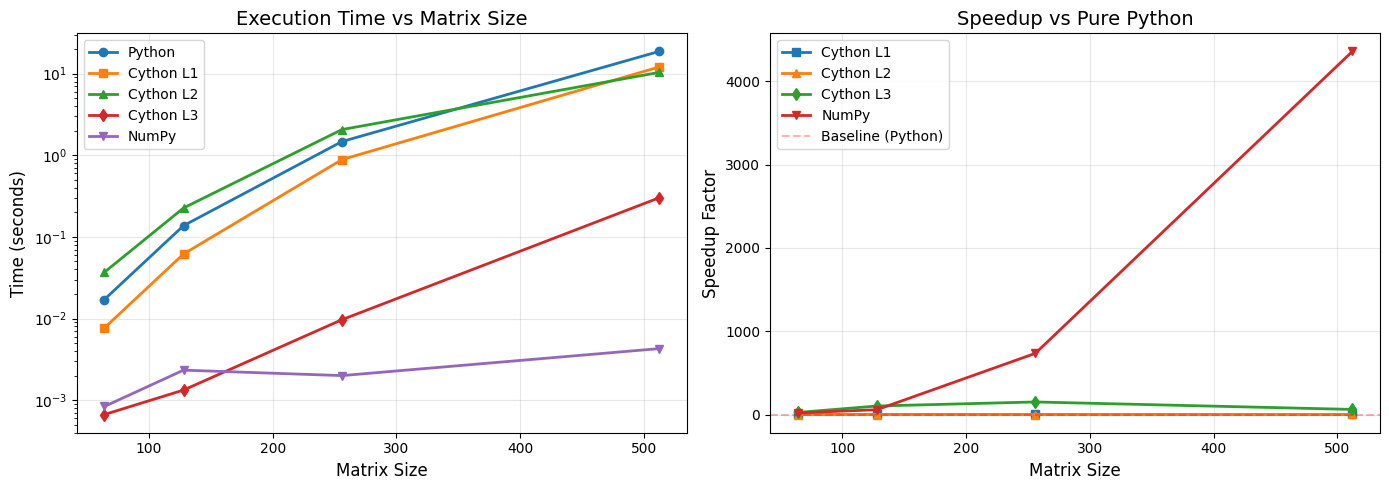

Figure saved as 'matmul_performance.png'


In [30]:
# Plot timing comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute timing
ax1.plot(sizes, python_times, 'o-', label='Python', linewidth=2)
ax1.plot(sizes, cython_level1_times, 's-', label='Cython L1', linewidth=2)
ax1.plot(sizes, cython_level2_times, '^-', label='Cython L2', linewidth=2)
ax1.plot(sizes, cython_level3_times, 'd-', label='Cython L3', linewidth=2)
ax1.plot(sizes, numpy_times, 'v-', label='NumPy', linewidth=2)
ax1.set_xlabel('Matrix Size', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time vs Matrix Size', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Speedup comparison
ax2.plot(sizes, df['Speedup L1'], 's-', label='Cython L1', linewidth=2)
ax2.plot(sizes, df['Speedup L2'], '^-', label='Cython L2', linewidth=2)
ax2.plot(sizes, df['Speedup L3'], 'd-', label='Cython L3', linewidth=2)
ax2.plot(sizes, df['Speedup NumPy'], 'v-', label='NumPy', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='Baseline (Python)')
ax2.set_xlabel('Matrix Size', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title('Speedup vs Pure Python', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'matmul_performance.png'")

### Reflection Questions

Answer the following questions based on your results. Write 2-3 sentences for each.

#### Q1: What was the speedup from Level 1 (basic Cython) compared to pure Python?

**Your Answer:**

Even though no explicit type declarations were added, Cython still compiles the Python code into a C extension module. Basically,the function call overhead is reduced and some Python-level interpretation steps are bypassed because of which on average it was **2** times faster

#### Q2: What additional speedup did you get from adding type declarations (Level 2)?

**Your Answer:**

I only got the same speed as the Cython level 1, which is somewhat **2** times faster than the normal Python Implementatiuon. By declaring loop counters and accumulator variables (i, j, k, acc) as C types, Cython can generate efficient C-level operations instead of slower Python object manipulations. This reduces dynamic type checking and function call overhead inside the loops.

#### Q3: Why did Level 3 (memory views) provide the biggest speedup?

**Your Answer:**

Level 3 provided the biggest speedup because it uses Cython memory views on NumPy arrays, allowing direct access to raw C-contiguous memory without any Python-layer overhead.
The nested loops with every array element is accessed as a plain C double, instead of as a Python object, eliminating the cost of dynamic type checks and Python function calls.
By disabling safety checks like boundscheck and wraparound, the code runs even closer to pure C performance.

#### Q4: How does your best Cython implementation compare to NumPy? Why is NumPy still faster?

**Your Answer:**

NumPy is still faster because it’s built on top of highly optimized BLAS and LAPACK libraries written in C.
These libraries make use of SIMD vectorization, cache-optimized memory access, and multithreading, which allow them to perform matrix operations much more efficiently than a simple triple loop.So, NumPy benefits from years of low-level optimization and hardware tuning but Cython still performs straightforward element-wise operations without those advanced optimizations.

#### Q5: When would you use Cython instead of NumPy for numerical computing?

**Your Answer:**

Cython is used when custom algrithms that NumPy doesn't support.NumPy is great for array math (matrix multiplication, FFTs, etc.) 
But they can’t easily express custom loops, branching logic, or irregular computations.

#### Q6: What are the trade-offs of using Cython? (Consider development time, debugging, portability)

**Your Answer:**

While Cython provides huge performance boosts, it also comes with a few trade-offs. Development time increases since I need to handle type declarations, compilation steps, and deal with occasional C-level errors. Debugging becomes more difficult because errors in the generated C code aren’t always easy to trace from Python.
It also reduces portability like compiled Cython files depend on the system’s C compiler and so they need to be rebuilt on different platforms.

---

## Submission Checklist

Before submitting, verify:

- [ ] All code cells have been executed (outputs are visible)
- [ ] All four Cython levels are implemented
- [ ] Timing results are present for all test cases
- [ ] Summary table is generated
- [ ] Visualization is displayed
- [ ] All six reflection questions are answered
- [ ] Used "Restart & Run All" before submission

**Submit this notebook (.ipynb file) with all outputs visible.**